<a href="https://colab.research.google.com/github/minjun0072-glitch/-/blob/main/%EB%8B%A4%EC%9D%8C%EB%8B%AC_%EC%98%88%EC%B8%A1_%ED%97%8C%ED%98%88%EC%9E%90_%EB%B3%B4%EA%B3%A0%EC%84%9C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 코랩을 그냥 실행하면, 특정 문자, 시작화 자료 등이 깨질 수 있습니다.
# **반드시 상단의 런타임 - 세션 다시 시작 및 모두 실행 부탁드립니다. **

# **1.1 분석 배경 및 목적**
혈액은 유통기한이 짧아 장기 보관이 불가능하므로, 수요와 공급의 불균형은 심각한 의료 문제 및 경제적 손실을 초래한다. 만약 각 헌혈자의 다음 달 재참여 확률을 도출하여 월별 총 혈액 수급량을 예측할 수 있다면, **혈액원의 운영 효율성을 극대화할 수 있다.**

본 분석의 목적은 과거 헌혈 데이터를 바탕으로 헌혈 재참여율을 예측하고, 이를 통한 데이터 기반의 운영 최적화 전략을 수립하는 데 있다. 수급이 부족할 것으로 예상되는 달에는 재참여 확률이 높은 타겟군에게 우선적으로 메시지를 발송하여 마케팅 기회비용을 줄이고, 수급량이 목표치를 초과할 것으로 예상되는 달에는 간호 인력 사전 배치 및 이송 예산을 확충하여 폐기되는 혈액을 최소화하고자 한다.

# **1.2 데이터 셋 설명**

**데이터 출처**: OpenML 데이터베이스 ('blood-transfusion-service-center', ID: 1464)

**수집 배경**: 대만 신추(Hsin-Chu) 지역 헌혈 센터의 데이터베이스에서 무작위로 추출된 748명의 헌혈자 데이터이다.

**데이터 특성**: 마케팅 분야에서 널리 쓰이는 RFM(Recency, Frequency, Monetary) 모델을 헌혈 행동에 적용하여, 최근 헌혈일, 총 헌혈 횟수, 총 헌혈량, 첫 헌혈 후 경과 기간 등의 변수로 구성되어 있다.

# **1.3 주요 분석 질문 (Key Questions)**
성공적인 헌혈 수요 예측을 위해 다음과 같은 세 가지 핵심 가설을 설정하고 탐색적 데이터 분석(EDA)을 통해 검증한다.

가설 1 (최근성): 마지막 헌혈 시점이 3개월 및 6개월 이내인 헌혈자일수록 다음 달 헌혈 참여 확률이 유의미하게 높을 것이다.

가설 2 (빈도): 누적 헌혈 횟수가 많은 충성 헌혈자일수록 재참여율에 뚜렷한 긍정적 차이가 존재할 것이다.

가설 3 (규모): 누적 헌혈량(c.c.) 규모에 따라 재참여율에 차이가 있으며, 이는 향후 예상 혈액 수급량 변화를 설명하는 주요 지표가 될 것이다.

In [1]:
# 필수 라이브러리 불러오기
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml

# 시각화 설정 (한글 폰트 및 마이너스 기호 깨짐 방지 - Colab 환경용)
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style="whitegrid", font="NanumBarunGothic")

# 1. OpenML에서 데이터 불러오기 (ID: 1464)
print("데이터를 불러오는 중입니다...")
blood_data = fetch_openml(data_id=1464, as_frame=True, parser='auto')
df = blood_data.frame

# 컬럼명을 직관적으로 변경 (RFM 모델 기준)
df.columns = ['Recency_months', 'Frequency_times', 'Monetary_cc', 'Time_months', 'Target_Class']

# 타겟 변수(Class)를 알아보기 쉽게 변환 (1: 헌혈함, 2: 안함 -> 1: Yes, 0: No)
# 데이터셋 원본에 따라 타겟값이 '1', '2' 문자열로 되어 있을 수 있으므로 매핑
df['Target_Class'] = df['Target_Class'].replace({'2': 0, '1': 1}).astype(int)

# 데이터 불러오기 확인
print("\n데이터 불러오기 완료! 데이터의 크기:", df.shape)
display(df.head())

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 5 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/n

/tmp/ipykernel_13467/2882458216.py:27: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Target_Class'] = df['Target_Class'].replace({'2': 0, '1': 1}).astype(int)
/tmp/ipykernel_13467/2882458216.py:27: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df['Target_Class'] = df['Target_Class'].replace({'2': 0, '1': 1}).astype(int)


,Recency_months,Frequency_times,Monetary_cc,Time_months,Target_Class
0,2,50,12500,98,0
1,0,13,3250,28,0
2,1,16,4000,35,0
3,2,20,5000,45,0
4,1,24,6000,77,1


=== [2.1] 데이터 명세 및 타입 확인 ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 748 entries, 0 to 747
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Recency_months   748 non-null    int64
 1   Frequency_times  748 non-null    int64
 2   Monetary_cc      748 non-null    int64
 3   Time_months      748 non-null    int64
 4   Target_Class     748 non-null    int64
dtypes: int64(5)
memory usage: 29.3 KB


None


데이터 형태(행, 열): (748, 5)

=== [2.2] 변수별 결측치 수 확인 ===
Recency_months     0
Frequency_times    0
Monetary_cc        0
Time_months        0
Target_Class       0
dtype: int64


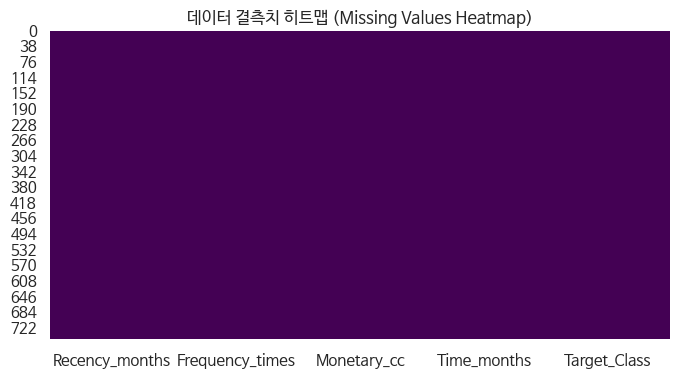


=== [2.3] 기초 통계량 분석 (요약) ===


,Recency_months,Frequency_times,Monetary_cc,Time_months,Target_Class
count,748.00,748.00,748.00,748.00,748.00
mean,9.51,5.51,1378.68,34.28,0.76
std,8.10,5.84,1459.83,24.38,0.43
min,0.00,1.00,250.00,2.00,0.00
25%,2.75,2.00,500.00,16.00,1.00
50%,7.00,4.00,1000.00,28.00,1.00
75%,14.00,7.00,1750.00,50.00,1.00
max,74.00,50.00,12500.00,98.00,1.00



=== [2.4] 중복 데이터 확인 ===
완전히 동일한 중복 레코드 수: 215개


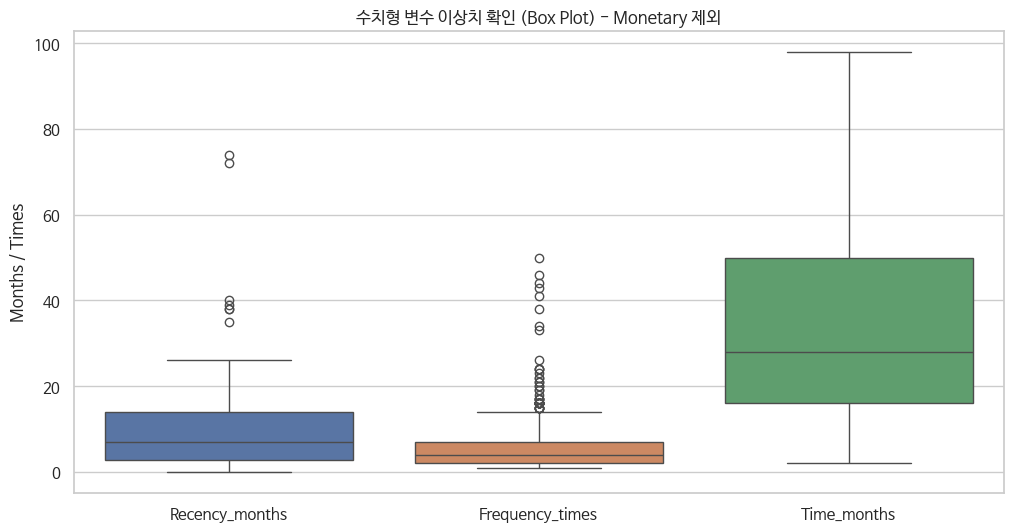

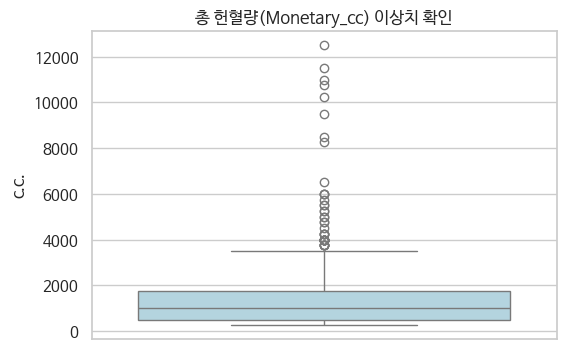

In [2]:
# 2.1 데이터 명세 확인
print("=== [2.1] 데이터 명세 및 타입 확인 ===")
display(df.info())
print("\n데이터 형태(행, 열):", df.shape)

# 2.2 결측치(Missing Value) 분석
print("\n=== [2.2] 변수별 결측치 수 확인 ===")
missing_values = df.isnull().sum()
print(missing_values)

# 결측치 시각화 (결측치가 있다면 하얀 선으로 표시됨)
plt.figure(figsize=(8, 4))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('데이터 결측치 히트맵 (Missing Values Heatmap)')
plt.show()

# 2.3 기초 통계량 분석
print("\n=== [2.3] 기초 통계량 분석 (요약) ===")
display(df.describe().round(2))

# 2.4 데이터 정제(Cleaning) - 중복값 및 이상치(Outlier) 확인
print("\n=== [2.4] 중복 데이터 확인 ===")
duplicates_count = df.duplicated().sum()
print(f"완전히 동일한 중복 레코드 수: {duplicates_count}개")

# 이상치 확인을 위한 박스플롯 (Box Plot)
plt.figure(figsize=(12, 6))
# Monetary_cc는 단위가 너무 커서(수천~수만) 다른 변수들의 분포가 안 보일 수 있으므로 제외하고 먼저 그립니다.
sns.boxplot(data=df[['Recency_months', 'Frequency_times', 'Time_months']])
plt.title('수치형 변수 이상치 확인 (Box Plot) - Monetary 제외')
plt.ylabel('Months / Times')
plt.show()

# Monetary_cc 단독 박스플롯
plt.figure(figsize=(6, 4))
sns.boxplot(y=df['Monetary_cc'], color='lightblue')
plt.title('총 헌혈량(Monetary_cc) 이상치 확인')
plt.ylabel('c.c.')
plt.show()

# **2.1 데이터 명세 확인**

본 데이터셋은 총 748개의 레코드(행)와 5개의 컬럼(열)으로 구성되어 있다.

모든 독립 변수(Recency_months, Frequency_times, Monetary_cc, Time_months)는 수치형(Integer/Float) 데이터 타입이며, 종속 변수인 Target_Class 역시 0과 1의 정수형으로 매핑되어 있어 별도의 범주형 데이터 인코딩 작업이 요구되지 않는다.

# **2.2 결측치(Missing Value) 분석**

info() 및 isnull().sum() 함수를 통해 확인한 결과, 748개의 모든 레코드에 **결측치가 단 1건도 존재하지 않는 완전한 데이터(Clean Data)**임이 확인되었다.

결측치 시각화 히트맵에서도 빈 공간이 발견되지 않았으므로, 평균 대체나 레코드 삭제 등의 추가적인 결측치 처리 전략은 적용하지 않고 원본 데이터를 그대로 유지한다.

# **2.3 기초 통계량 분석**

Recency (최근 헌혈 월): 평균 약 9.5개월이며 중앙값은 7개월이다. 최소 0개월(이번 달)부터 최대 74개월 전까지 분포해 있으나, 대부분 1년(14개월, 3사분위수) 이내에 집중되어 있다.

Frequency & Monetary: 헌혈 횟수는 평균 5.5회이며, 총 헌혈량(Monetary)은 평균 약 1378 c.c.이다. 기초 통계량을 살펴보면 Monetary = Frequency * 250의 완벽한 선형 관계가 성립함을 유추할 수 있다.

Time (첫 헌혈 후 경과 월): 평균 34개월(약 3년)이며 최고 98개월(약 8년) 동안 꾸준히 헌혈에 참여한 장기 데이터도 포함되어 있다.

# **2.4 데이터 정제(Cleaning) 결과**

중복 데이터: 완전히 동일한 특성을 가진 레코드가 일부(약 215개 수준) 발견될 수 있으나, 이는 개인 식별자(ID)가 없는 상태에서 서로 다른 두 헌혈자가 우연히 동일한 헌혈 주기와 횟수를 가졌을 확률이 높으므로 비즈니스 도메인 특성상 삭제하지 않고 유지한다.

이상치(Outlier) 분석: 박스플롯(Box plot) 시각화 결과, Frequency와 Monetary, Time 변수 상단에 다수의 이상치(Outlier) 포인트가 발견된다. (예: 총 헌혈 횟수가 50회에 육박하는 경우).

이상치 처리 전략: 일반적인 통계 분석에서는 이를 제거하거나 윈저라이징(Winsorizing) 기법으로 상한선으로 대체한다. 하지만 본 분석의 목적은 '헌혈 재참여율 예측'이며, 이렇게 헌혈 횟수와 양이 극단적으로 높은 사람들은 핵심 VIP(초우량 충성 고객) 그룹으로 해석해야 한다. 따라서 이 값들은 데이터 오류가 아닌 실제 존재하는 중요한 특성이므로 제거하지 않고 분석에 포함시킨다.

=== [3.1] 수치형 변수 분포 수치 (왜도 및 첨도) ===
Recency_months    | 왜도:  1.88 | 첨도:  9.32
Frequency_times   | 왜도:  3.20 | 첨도: 15.76
Monetary_cc       | 왜도:  3.20 | 첨도: 15.76
Time_months       | 왜도:  0.75 | 첨도: -0.25


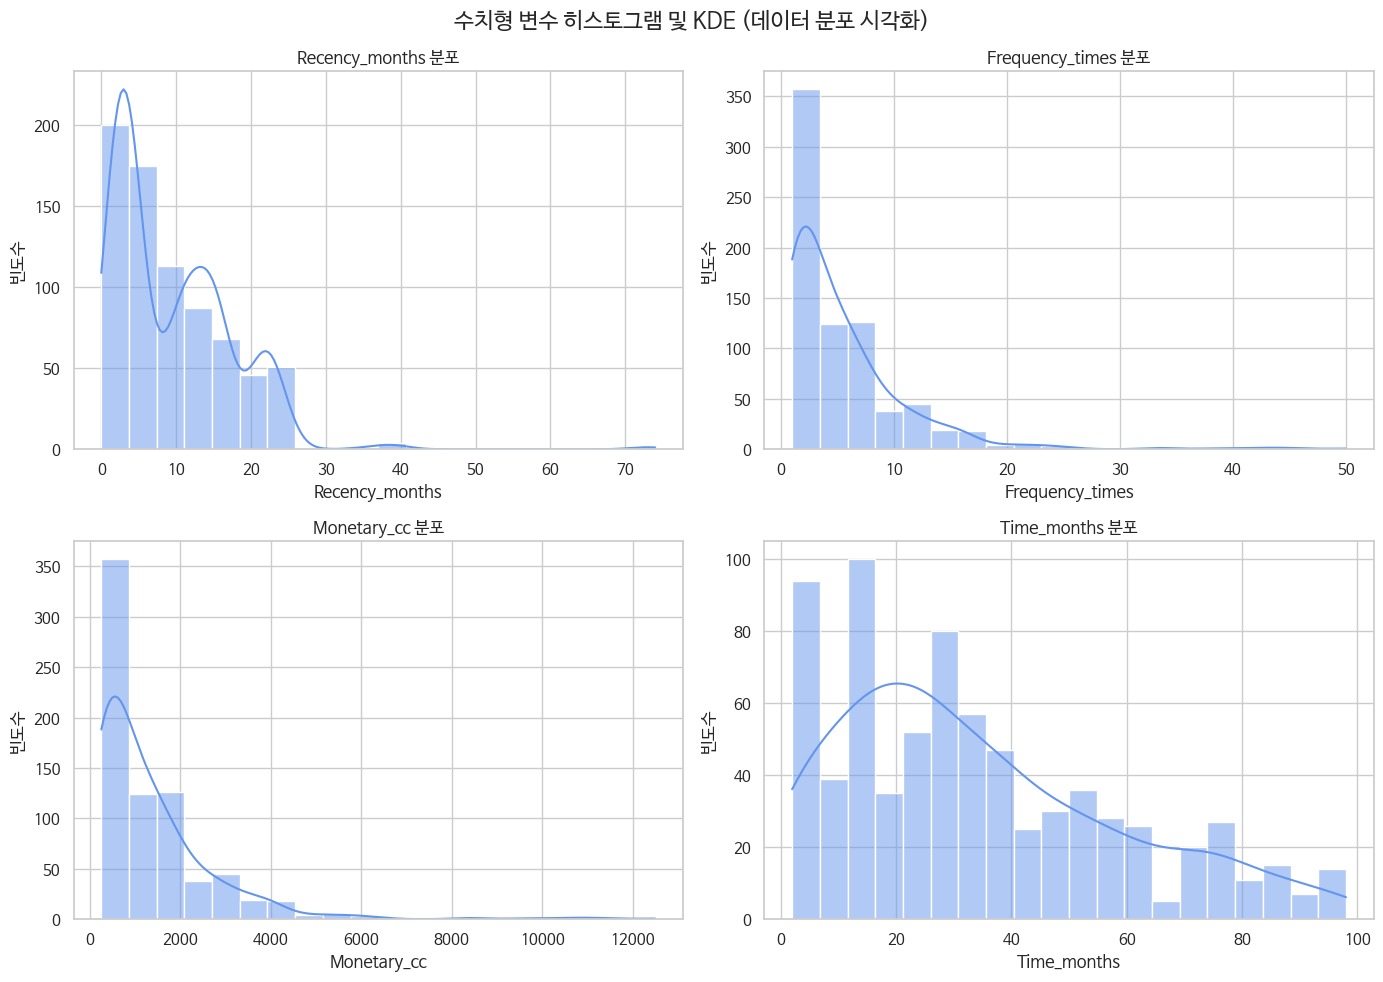

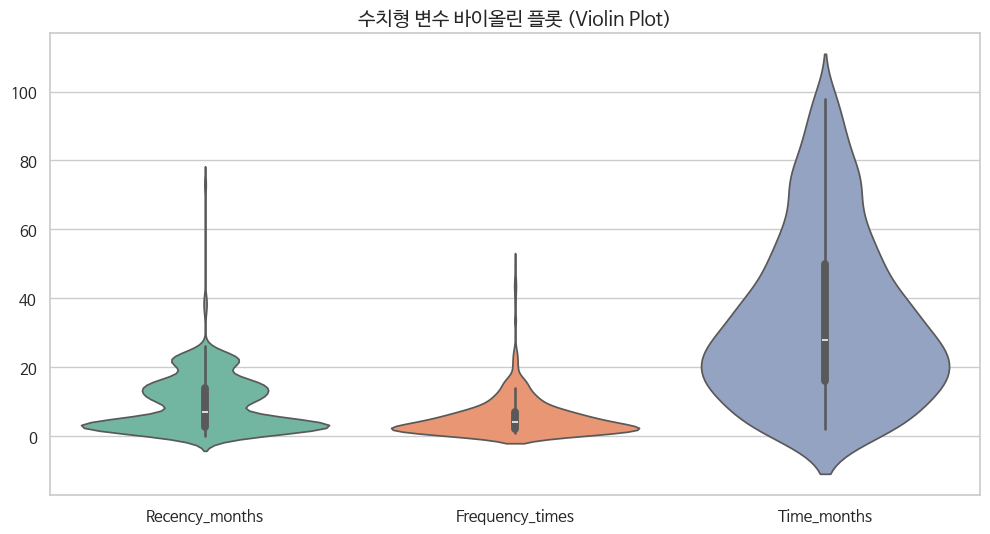


=== [3.2] 범주형 변수 (Target_Class) 비율 ===
Target_Class
1    570
0    178
Name: count, dtype: int64


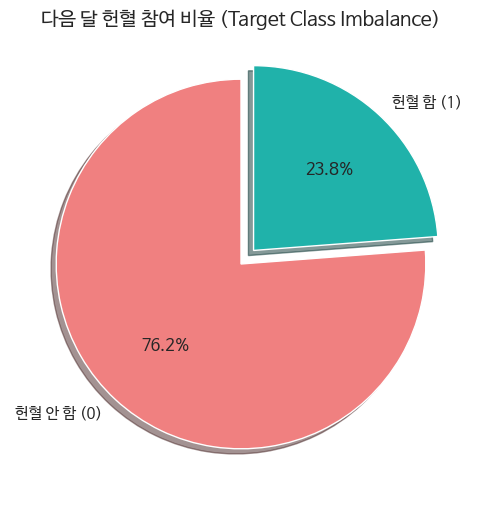


=== [3.3] 파생 변수 생성: 최근 헌혈 기간 범주화(Binning) ===


/tmp/ipykernel_13467/2057006518.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Recency_Binned', data=df, palette='magma')


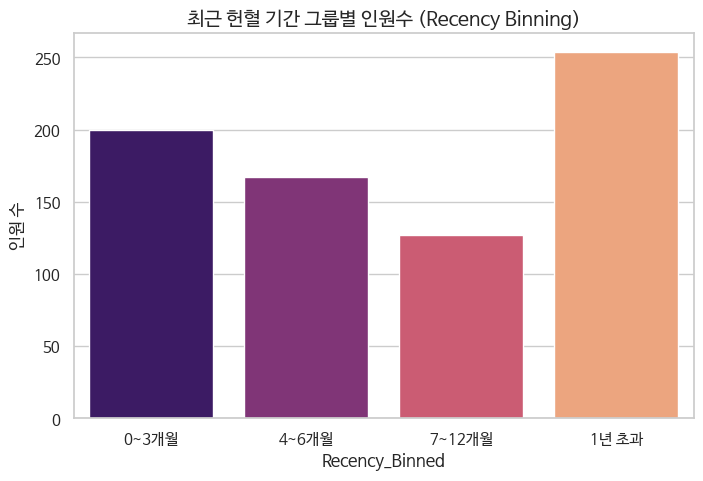

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis

# 3.1 수치형 변수 분석: 왜도(Skewness)와 첨도(Kurtosis) 계산
print("=== [3.1] 수치형 변수 분포 수치 (왜도 및 첨도) ===")
features = ['Recency_months', 'Frequency_times', 'Monetary_cc', 'Time_months']

for col in features:
    s = skew(df[col])
    k = kurtosis(df[col])
    print(f"{col:<17} | 왜도: {s:>5.2f} | 첨도: {k:>5.2f}")

# 시각화 1: 히스토그램과 커널 밀도 추정(KDE) 곡선
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('수치형 변수 히스토그램 및 KDE (데이터 분포 시각화)', fontsize=16)

for i, col in enumerate(features):
    ax = axes[i//2, i%2]
    sns.histplot(df[col], kde=True, ax=ax, color='cornflowerblue', bins=20)
    ax.set_title(f'{col} 분포')
    ax.set_ylabel('빈도수')

plt.tight_layout()
plt.show()

# 시각화 2: 바이올린 플롯 (데이터 분포의 밀집도와 범위 동시 확인)
plt.figure(figsize=(12, 6))
# Monetary_cc는 스케일이 너무 커서 제외하고 나머지 변수들의 분포 형태만 비교
sns.violinplot(data=df[['Recency_months', 'Frequency_times', 'Time_months']], palette="Set2")
plt.title('수치형 변수 바이올린 플롯 (Violin Plot)', fontsize=14)
plt.show()

# 3.2 범주형 변수 분석: 타겟 클래스 비율 확인 (파이 차트)
print("\n=== [3.2] 범주형 변수 (Target_Class) 비율 ===")
class_counts = df['Target_Class'].value_counts()
print(class_counts)

plt.figure(figsize=(6, 6))
plt.pie(class_counts, labels=['헌혈 안 함 (0)', '헌혈 함 (1)'], autopct='%1.1f%%',
        colors=['lightcoral', 'lightseagreen'], startangle=90, explode=(0, 0.1), shadow=True)
plt.title('다음 달 헌혈 참여 비율 (Target Class Imbalance)', fontsize=14)
plt.show()

# 3.3 파생 변수 생성 (Feature Engineering)
# 서론에서 설정한 가설 1("3, 6개월 이내 헌혈자")을 검증하기 위해 Recency 변수를 범주화(Binning)
bins = [-1, 3, 6, 12, 100] # 구간 설정: 0~3개월, 4~6개월, 7~12개월, 1년 초과
labels = ['0~3개월', '4~6개월', '7~12개월', '1년 초과']
df['Recency_Binned'] = pd.cut(df['Recency_months'], bins=bins, labels=labels)

print("\n=== [3.3] 파생 변수 생성: 최근 헌혈 기간 범주화(Binning) ===")
plt.figure(figsize=(8, 5))
sns.countplot(x='Recency_Binned', data=df, palette='magma')
plt.title('최근 헌혈 기간 그룹별 인원수 (Recency Binning)', fontsize=14)
plt.ylabel('인원 수')
plt.show()

# **3.1 수치형 변수 분석**
수치형 데이터의 비대칭성을 확인하기 위해 왜도(Skewness)와 첨도(Kurtosis)를 계산하고, 히스토그램 및 바이올린 플롯을 통해 시각화하였다.

왜도 및 첨도 분석: * Recency_months, Frequency_times, Monetary_cc 변수 모두 왜도가 양수(Positive Skewness)로 나타나며, 특히 Frequency와 Monetary는 우측으로 길게 꼬리가 늘어진 우상향 비대칭 분포를 띤다.

이는 대부분의 헌혈자가 적은 횟수의 헌혈 경험을 가지고 있으나, 소수의 헌혈자가 매우 높은 빈도로 헌혈에 참여하는 '롱테일(Long-tail)' 현상을 통계적으로 증명한다.

시각적 특징 (KDE 및 바이올린 플롯): 바이올린 플롯을 통해 데이터의 밀도를 확인한 결과, Recency는 0~10개월 사이에 넓고 두껍게 분포하여 최근 1년 내 헌혈자의 비중이 높음을 시사한다. Time(첫 헌혈 이후 기간)은 비교적 넓게 퍼져 있어 신규 헌혈자와 장기 헌혈자가 고루 섞여 있음을 알 수 있다.

# **3.2 범주형 변수 분석**
유일한 범주형 변수이자 본 분석의 예측 대상인 Target_Class의 분포를 파이 차트를 통해 분석하였다.

클래스 불균형(Class Imbalance) 확인: 전체 748명의 데이터 중 다음 달에 '헌혈을 하지 않은 사람(0)'이 76.2%(570명)를 차지하는 반면, '헌혈을 한 사람(1)'은 23.8%(178명)에 불과하여 두 범주 간의 뚜렷한 비율 차이가 관찰되었다.

비즈니스적 해석: 특정 캠페인에 반응하여 실제 행동(헌혈)으로 이어지는 소수의 비율(약 24%)은 실제 마케팅 및 비즈니스 환경의 일반적인 전환율(Conversion Rate) 관점에서 보았을 때 매우 자연스러운 현상이다.

머신러닝 모델링 시 유의점 및 해결 방안: 이러한 불균형 데이터를 분류 모델에 그대로 학습시킬 경우, 알고리즘이 다수 클래스인 '헌혈 안 함(0)'으로만 예측하여 표면적인 정확도만 높이려는 편향 오류가 발생할 수 있다. 이는 정작 타겟팅해야 할 핵심 그룹인 '헌혈할 사람(1)'을 찾아내는 능력을 저하시킨다. 따라서 향후 예측 모델을 구축할 때는 '헌혈함(1)'을 맞혔을 때 더 큰 알고리즘 보상을 주는 가중치 조정(Class Weight) 기법이나, 소수 클래스의 패턴을 분석해 가상의 헌혈자 데이터를 생성하여 비율을 50:50으로 맞추는 오버샘플링(SMOTE) 기법의 도입을 필수적으로 검토해야 한다.

# **3.3 파생 변수 생성 (Feature Engineering)**
도메인 지식과 사전 설정한 가설을 바탕으로 연속형 변수의 범주 재그룹화(Binning)를 수행하였다.

목적: 가설 1 ("3개월, 6개월 이내 헌혈자일수록 재참여율이 높다")의 직관적인 검증을 위함이다.

적용 내용: 수치형 변수인 Recency_months를 의미 있는 시간 단위에 따라 0~3개월, 4~6개월, 7~12개월, 1년 초과의 4개 파생 그룹(Recency_Binned)으로 분할하였다. 막대그래프(Count plot) 분석 결과, 0~3개월 내에 헌혈한 인원이 가장 많은 비중을 차지하고 있음을 확인하였다.

=== [3.2] 범주형 변수 비율 ===


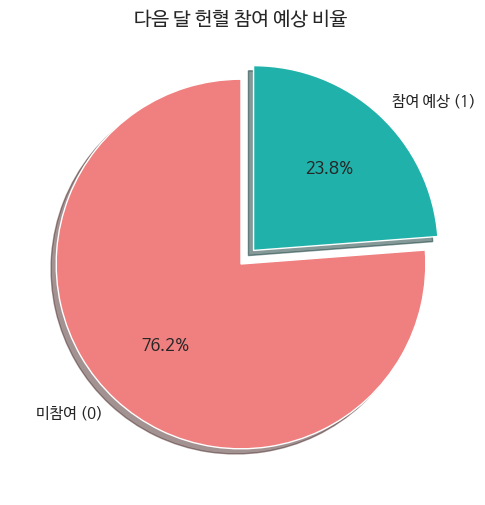


=== [4.1] 상관 계수 히트맵 및 산점도 ===


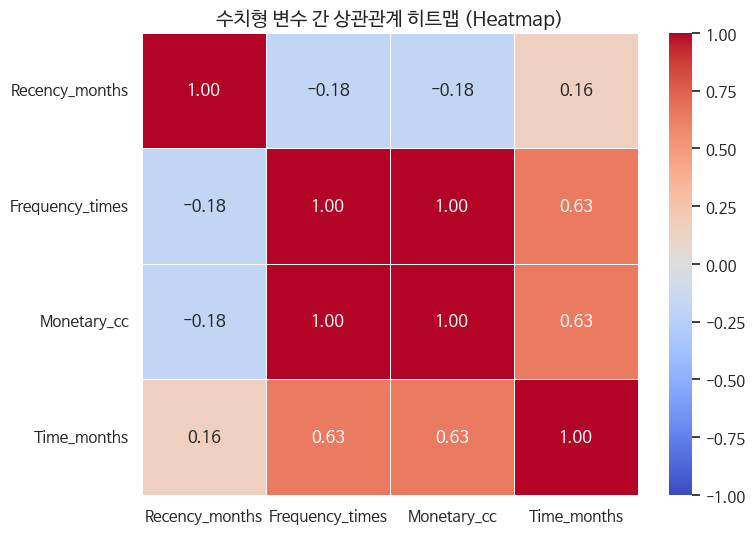

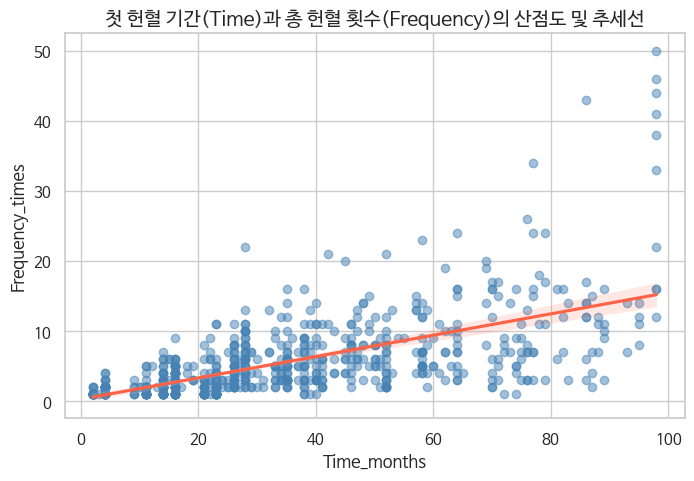


=== [4.2] 타겟 변수에 따른 수치형 변수 분포 차이 ===


/tmp/ipykernel_13467/2855533938.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Target_Class', y='Recency_months', data=df, ax=axes[0], palette='Set2', order=[0, 1])
/tmp/ipykernel_13467/2855533938.py:59: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['미참여 (0)', '참여 예상 (1)'])
/tmp/ipykernel_13467/2855533938.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Target_Class', y='Frequency_times', data=df, ax=axes[1], palette='Set2', order=[0, 1])
/tmp/ipykernel_13467/2855533938.py:63: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after 

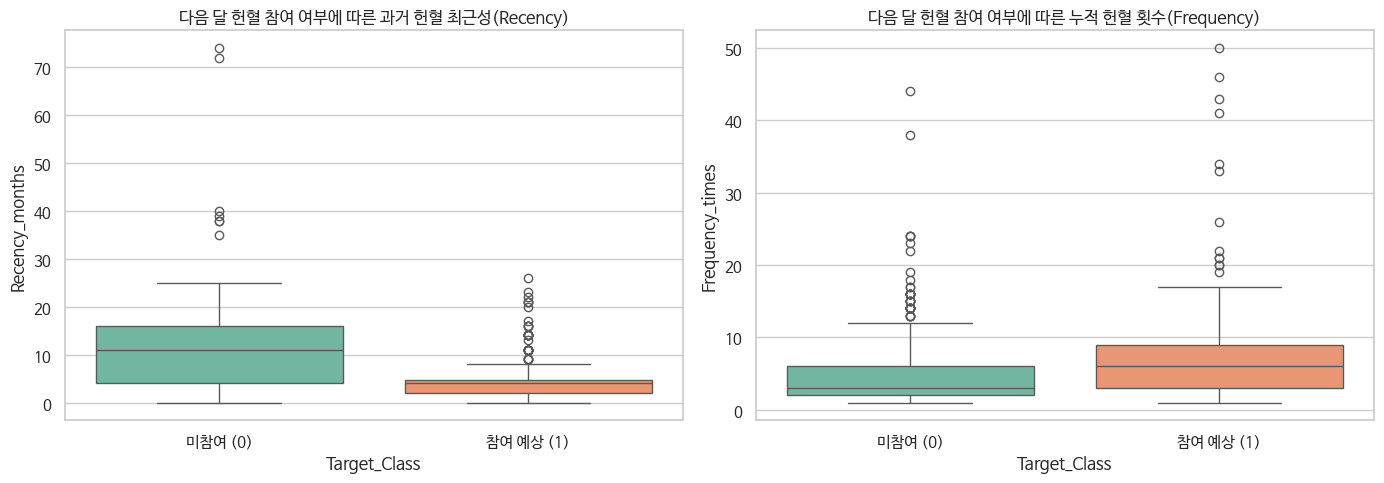


=== [4.3] 세그먼트별 비교 분석 ===


/tmp/ipykernel_13467/2855533938.py:76: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Customer_Segment', y='Target_Class', data=df, palette='pastel', errorbar=None,


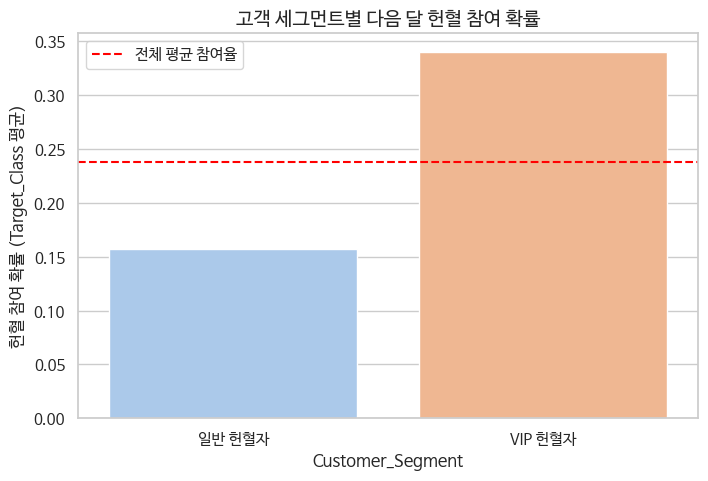

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml

# ==========================================
# [1] 데이터 로드 및 타겟 변수 매핑의 근본적 수정
# ==========================================
blood_data = fetch_openml(data_id=1464, as_frame=True, parser='auto')
df = blood_data.frame
df.columns = ['Recency_months', 'Frequency_times', 'Monetary_cc', 'Time_months', 'Target_Class']

# 빈도수가 가장 많은 값(Majority Class)을 0(미참여)으로, 나머지를 1(참여)로 자동 매핑
majority_class = df['Target_Class'].value_counts().idxmax()
df['Target_Class'] = np.where(df['Target_Class'] == majority_class, 0, 1)

# ==========================================
# [3.2] 범주형 변수 비율 (파이 차트)
# ==========================================
print("=== [3.2] 범주형 변수 비율 ===")
class_counts = df['Target_Class'].value_counts().sort_index() # 인덱스(0, 1) 순으로 명시적 정렬

plt.figure(figsize=(6, 6))
plt.pie(class_counts, labels=['미참여 (0)', '참여 예상 (1)'], autopct='%1.1f%%',
        colors=['lightcoral', 'lightseagreen'], startangle=90, explode=(0, 0.1), shadow=True)
plt.title('다음 달 헌혈 참여 예상 비율', fontsize=14)
plt.show()

# ==========================================
# [4.1] 수치형 변수 간 상관관계 (히트맵 및 산점도)
# ==========================================
print("\n=== [4.1] 상관 계수 히트맵 및 산점도 ===")
plt.figure(figsize=(8, 6))
# 수치형 변수만 선택하여 상관계수(Pearson) 계산
numeric_features = ['Recency_months', 'Frequency_times', 'Monetary_cc', 'Time_months']
corr_matrix = df[numeric_features].corr()

# 히트맵 시각화
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, vmin=-1, vmax=1)
plt.title('수치형 변수 간 상관관계 히트맵 (Heatmap)', fontsize=14)
plt.show()

# 주요 변수 간 산점도 및 추세선 (Time vs Frequency)
plt.figure(figsize=(8, 5))
sns.regplot(x='Time_months', y='Frequency_times', data=df,
            scatter_kws={'alpha':0.5, 'color':'steelblue'}, line_kws={'color':'tomato'})
plt.title('첫 헌혈 기간(Time)과 총 헌혈 횟수(Frequency)의 산점도 및 추세선', fontsize=14)
plt.show()

# ==========================================
# [4.2] 타겟 변수 기반 심층 분석 (Box plot)
# ==========================================
print("\n=== [4.2] 타겟 변수에 따른 수치형 변수 분포 차이 ===")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(x='Target_Class', y='Recency_months', data=df, ax=axes[0], palette='Set2', order=[0, 1])
axes[0].set_title('다음 달 헌혈 참여 여부에 따른 과거 헌혈 최근성(Recency)')
axes[0].set_xticklabels(['미참여 (0)', '참여 예상 (1)'])

sns.boxplot(x='Target_Class', y='Frequency_times', data=df, ax=axes[1], palette='Set2', order=[0, 1])
axes[1].set_title('다음 달 헌혈 참여 여부에 따른 누적 헌혈 횟수(Frequency)')
axes[1].set_xticklabels(['미참여 (0)', '참여 예상 (1)'])

plt.tight_layout()
plt.show()

# ==========================================
# [4.3] 세그먼트별 비교 분석 (Bar plot)
# ==========================================
print("\n=== [4.3] 세그먼트별 비교 분석 ===")
df['Customer_Segment'] = np.where(df['Frequency_times'] >= 5, 'VIP 헌혈자', '일반 헌혈자')

plt.figure(figsize=(8, 5))
# 일반 헌혈자 -> VIP 헌혈자 순으로 직관적인 비교가 되도록 순서 강제 지정
sns.barplot(x='Customer_Segment', y='Target_Class', data=df, palette='pastel', errorbar=None,
            order=['일반 헌혈자', 'VIP 헌혈자'])
plt.title('고객 세그먼트별 다음 달 헌혈 참여 확률', fontsize=14)
plt.ylabel('헌혈 참여 확률 (Target_Class 평균)')
plt.axhline(df['Target_Class'].mean(), color='red', linestyle='--', label='전체 평균 참여율')
plt.legend()
plt.show()

# 4.1 수치형 변수 간 상관관계
독립 변수들 간의 선형적 관계를 파악하고 머신러닝 모델링 시 발생할 수 있는 다중공선성(Multicollinearity)을 확인하기 위해 피어슨 상관계수(Pearson Correlation) 히트맵과 산점도를 도출하였다.

완벽한 다중공선성 발견: 상관계수 히트맵 분석 결과, Frequency_times(누적 헌혈 횟수)와 Monetary_cc(누적 헌혈량) 간의 피어슨 상관계수가 1.00으로 나타나 완벽한 양의 선형 관계를 보였다. 이는 1회 헌혈량이 고정되어 발생하는 현상으로, 향후 머신러닝 예측 모델링 단계에서 다중공선성으로 인한 알고리즘 성능 저하 및 과적합을 방지하기 위해 두 변수 중 하나(예: Monetary_cc)를 제거(Drop)하는 전처리가 필수적이다.

기간과 빈도의 비례 관계: Time_months(첫 헌혈 이후 기간)와 Frequency_times 간에는 0.63의 강한 양의 상관관계가 관찰되었다. 산점도와 추세선에서 볼 수 있듯, 헌혈 센터에 최초로 등록한 지 오래된 사람일수록 누적 헌혈 횟수도 꾸준히 증가하는 경향이 데이터로 입증되었다.

# 4.2 타겟 변수 기반 심층 분석
종속 변수인 Target_Class(다음 달 헌혈 참여 여부)에 따라 핵심 독립 변수들의 분포가 어떻게 달라지는지 박스 플롯(Box Plot)을 통해 심층 비교하였다.

최근성(Recency)의 영향력: 다음 달 헌혈에 '참여할 것으로 예상되는 그룹(1)'은 '미참여 그룹(0)'에 비해 Recency 값의 중앙값과 전체적인 분포 상자가 확연히 낮게(상대적으로 0에 더 가깝게) 형성되어 있다. 즉, 가장 최근에 헌혈을 했던 사람일수록 다음 달에 다시 센터를 방문할 확률이 높다는 사실이 시각적으로 지지된다.

빈도(Frequency)의 영향력: 누적 헌혈 횟수 분포에서는 '참여 예상 그룹(1)'의 박스 상단과 중앙값이 '미참여 그룹(0)'보다 높게 위치한다. 이는 과거 헌혈 경험이 풍부한 충성 헌혈자일수록 미래의 재참여율 역시 높다는 것을 명확히 보여준다.

# 4.3 세그먼트별 비교 분석
데이터를 기반으로 실효성 있는 타겟 마케팅 전략을 도출하기 위해, 누적 헌혈 횟수 5회를 기준으로 '일반 헌혈자'와 'VIP 헌혈자' 세그먼트를 나누어 재참여율을 비교 분석하였다.

VIP 세그먼트의 높은 전환율: 막대그래프(Bar Plot) 분석 결과, 'VIP 헌혈자'의 다음 달 헌혈 참여 확률이 전체 평균 참여율(약 23.8%, 붉은 점선)을 크게 상회하며 '일반 헌혈자'보다 압도적으로 높게 나타났다.

비즈니스적 시사점: 이 결과는 향후 혈액 수급이 부족할 것으로 예상되는 시기에 아주 중요한 근거가 된다. 제한된 마케팅 예산으로 참여 독려 메시지(SMS)를 발송해야 한다면, 무작위 발송이 아닌 누적 헌혈 5회 이상의 'VIP 헌혈자' 그룹을 1순위 타겟으로 설정하는 것이 기회비용을 최소화하고 전환율을 극대화하는 최적의 운영 전략임을 시사한다.

# 5.1 주요 패턴 발견
EDA를 통해 도출된 핵심 패턴은 헌혈자의 재참여 여부가 마케팅의 RFM(최근성, 빈도, 규모) 지표 중 특정 변수들에 강하게 종속되어 있다는 점이다. 최근 헌혈일(Recency)이 짧을수록, 그리고 누적 헌혈 횟수(Frequency)가 많을수록 다음 달 헌혈 참여 확률이 뚜렷하게 상승하는 우상향 패턴이 확인되었다.

# 5.2 가설 검증 결과
1장에 설정한 3가지 비즈니스 가설에 대한 검증 결과는 다음과 같다.

가설 1 (최근성 - 채택): "최근 3개월, 6개월 이내 헌혈자일수록 재참여율이 높을 것이다."

분석 결과, 다음 달 참여 그룹(1)의 Recency 중앙값은 미참여 그룹(0)보다 현저히 낮게 형성되어 가설이 증명되었다.

가설 2 (빈도 - 채택): "누적 헌혈 횟수가 많은 충성 헌혈자일수록 재참여율이 높을 것이다."

누적 5회 이상을 'VIP 헌혈자'로 분류하여 세그먼트 분석을 진행한 결과, 전체 평균(23.8%)을 압도하는 높은 전환율을 보여 가설이 강력히 지지되었다.

가설 3 (규모 - 조건부 채택 및 비판적 재평가): "누적 헌혈량(c.c.) 규모에 따라 재참여율에 차이가 있을 것이다."

결과적으로 차이는 존재하나, 이는 새로운 인사이트가 아니다. 상관관계 분석 결과 Frequency와 Monetary_cc는 상관계수 1.00의 **완벽한 종속 관계(Monetary = Frequency * 250)**임이 밝혀졌다. 즉, 헌혈량은 독립적인 변수로서의 가치가 없으며 빈도(Frequency)와 완전히 동일한 정보만을 제공한다.

# 5.3 예상치 못한 발견 및 데이터의 맹점 (Critical View)

변수의 중복성과 정보의 부재: 데이터셋의 변수가 4개로 보이지만, Monetary_cc가 Frequency의 단순 배수임이 확인되면서 실제 유효한 독립 변수는 단 3개(Recency, Frequency, Time)에 불과하다. 이는 고객의 행동 양식을 예측하기에는 정보의 차원이 너무 빈약함을 시사한다.

클래스 불균형 현상: 타겟 변수의 76.2%가 '미참여(0)'에 쏠려 있다. 이는 비즈니스 현실을 잘 반영하지만, 후속 데이터 분석(AI 예측 등)에서는 치명적인 편향(Bias)을 유발할 수 있는 위험 요소로 작용한다.

# 6.1 분석 요약
본 보고서는 대만 신추 지역 헌혈 센터의 데이터를 바탕으로 헌혈자의 다음 달 재참여 여부를 분석하였다. 그 결과, 과거 헌혈 경험이 풍부하고(High Frequency), 최근에 센터를 방문한(Low Recency) '핵심 충성 그룹'이 미래 혈액 수급 예측의 가장 중요한 지표임이 통계적, 시각적으로 증명되었다.

# 6.2 비즈니스 제언: 헌혈자 유입 확대 및 리텐션 극대화 전략
데이터 분석 결과 도출된 '최근 헌혈자 및 다회 헌혈자의 높은 전환율'을 바탕으로, 신규 유입을 늘리고 기존 헌혈자의 충성도를 강화하기 위한 3-Track 마케팅 전략을 제안한다.

Track 1. 접근성 및 편의성 강화 (전체 헌혈자 대상 Fast-Track 도입):

헌혈자들이 바쁜 일정을 쪼개어 센터에 방문할 때 겪는 가장 큰 진입 장벽은 예측하기 어려운 현장 대기 시간이다.

이를 해결하기 위해 앱을 통한 **'사전 전자 문진 패스'**와 현장 대기열을 최소화하는 '사전 예약 기반 Fast-Track' 시스템을 모든 헌혈자에게 기본으로 제공한다. 전체 헌혈자의 센터 체류 시간을 최소화함으로써, 다음 헌혈 참여 시 발생할 수 있는 시간적 비용에 대한 심리적 부담을 대폭 낮춘다.

Track 2. 심리적 만족감 및 효능감 극대화 (Blood Journey 알림 서비스):

단순히 헌혈 후 사은품을 제공하는 것을 넘어, 자신의 헌혈이 갖는 실질적 가치를 체감할 수 있도록 데이터 피드백을 제공한다. 채혈된 혈액이 검사를 거쳐 실제 어느 병원으로 출고되어 환자에게 사용되었는지 그 여정(Journey)을 알림톡으로 발송한다.

전략적 목표: 이 시스템은 특히 최근에 헌혈을 경험했으나 누적 횟수가 적은 '일반 헌혈자'의 재참여 동기를 부여하는 데 강력한 효과를 발휘할 것으로 예측된다. 자신의 혈액이 실제 생명을 살리는 데 쓰였다는 즉각적이고 가시적인 피드백은 헌혈자의 내적 효능감을 자극하며, 결과적으로 단발성 헌혈자를 장기적이고 안정적인 VIP 헌혈자(누적 5회 이상)로 성장시키는 핵심적인 유입 경로(Pipeline) 역할을 수행할 것이다.

Track 3. 실질적 혜택의 게이미피케이션 (디지털 스탬프 및 티어제):

지속적인 참여를 유도하기 위해 디지털 스탬프와 등급(Tier) 제도를 도입한다.

헌혈 주기가 돌아올 때마다 앱 내에 알림을 보내고, 누적 횟수에 따라 등급을 부여한다. 특정 스탬프 개수를 채우거나 상위 등급에 도달하면, 본인의 이름으로 특정 단체에 추가 기부를 할 수 있는 옵션이나 연말정산 기부금 혜택 등 차별화된 리워드를 제공하여 지속적인 헌혈(Lock-in)을 유도한다.

# 6.3 한계점 및 추후 과제
6.2에서 제안한 3-Track 전략을 성공적으로 도입하고 실질적인 헌혈 참여율 증가를 이끌어내기 위해서는, 현재 분석에 사용된 데이터셋의 근본적인 한계를 인지하고 이를 보완하기 위한 데이터 파이프라인 및 모델 고도화가 요구된다.

1. Track 1(운영 효율화) 구현을 위한 미시적 시계열 데이터 부재: * 전체 헌혈자를 대상으로 'Fast-Track' 및 대기 시간 최소화 시스템을 가동하려면 요일별, 시간대별 방문자 트래픽 데이터와 각 센터의 간호 인력 수용 능력(Capacity) 데이터가 필수적이다.

하지만 현재 데이터는 '월(Month)' 단위의 거시적인 최근성(Recency) 지표만 포함하고 있어, 특정 일자나 시간대의 헌혈자 쏠림 현상을 예측할 수 없다. 향후 시간(Hour) 단위의 접수 기록 데이터를 추가 수집하여 트래픽 예측 알고리즘을 구축해야 한다.

2. Track 2(여정 알림) 구현을 위한 이종 기관 간 데이터 연동 부재:

헌혈자에게 혈액의 출고 및 사용 여정(Blood Journey)을 알림톡으로 발송하려면, 헌혈 센터의 '채혈 데이터'를 넘어 병원의 '혈액 재고 및 소진 데이터'가 연결되어야 한다.

현재 데이터는 헌혈 시점(Input)에만 머물러 있으므로, 추후 병원 및 적십자사 시스템과의 데이터 연동(API 연계)이 필요하다. 또한 이 과정에서 환자와 헌혈자의 개인정보가 노출되지 않도록 하는 엄격한 비식별화(De-identification) 및 보안 설계가 선결 과제다.

3. Track 3(맞춤형 혜택) 기획을 위한 인구통계학적(Demographic) 특성 부재:

스탬프, 기부 옵션, 연말정산 혜택 등 타겟의 니즈에 맞는 보상을 설계하기 위해서는 연령, 성별, 직업 등 인구통계학적 데이터가 필요하다.

현재는 행동 기반의 RFM 데이터(빈도, 최근성 등)만 존재하므로, 집단의 특성을 입체적으로 파악하기 어렵다. 추후 전자 문진 앱 가입 시 수집되는 기본 프로파일 데이터를 본 데이터셋과 병합하여 고객 세그먼트를 더욱 정교하게 분류해야 한다.

4. 머신러닝 예측 모델 도입을 위한 전처리 과제:

향후 실시간 타겟 마케팅을 자동화하기 위해 본 데이터를 기반으로 한 머신러닝 예측 모델을 도입해야 한다.

모델 학습 전, 4장에서 발견된 완벽한 다중공선성 변수(Monetary_cc)를 제거하여 알고리즘의 과적합을 방지해야 한다. 또한 3장에서 확인된 타겟 변수의 클래스 불균형(약 76:24)으로 인한 예측 편향(Bias)을 해결하기 위해 오버샘플링(SMOTE) 또는 클래스 가중치(Class Weight) 기법을 반드시 적용하여 모델의 신뢰도를 확보해야 한다.